In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv(r"C:\Users\alha\Downloads\loan approval\loanapproval.csv")

df.columns = df.columns.str.strip()

print("Dataset Preview:\n")
print(df.head())

Dataset Preview:

   applicant_id  age  gender marital_status  annual_income  loan_amount  \
0             1   59    Male       Divorced         100073         7169   
1             2   49    Male        Married         112197        23556   
2             3   35    Male       Divorced          84429        27052   
3             4   63  Female         Single         124195        11313   
4             5   28  Female        Married          81627        13315   

   credit_score  num_dependents  existing_loans_count employment_status  \
0           793               1                     1        Unemployed   
1           789               0                     2          Employed   
2           372               1                     4        Unemployed   
3           808               3                     4     Self-employed   
4           689               0                     1        Unemployed   

   loan_approved  
0              1  
1              1  
2              0  
3   

In [3]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())


Missing Values After Cleaning:

applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64


In [4]:
label_encoder = LabelEncoder()

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])


In [6]:
X = df.drop("existing_loans_count", axis=1)

y = df["existing_loans_count"]

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain-Test Shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


Train-Test Shapes:
X_train: (800, 10)
X_test : (200, 10)


In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
y_pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy Score: 0.265

Classification Report:

              precision    recall  f1-score   support

           0       0.16      0.11      0.13        37
           1       0.29      0.49      0.36        45
           2       0.12      0.06      0.08        36
           3       0.25      0.27      0.26        37
           4       0.35      0.33      0.34        45

    accuracy                           0.27       200
   macro avg       0.23      0.25      0.23       200
weighted avg       0.24      0.27      0.24       200




Confusion Matrix:

[[ 4 18  3  7  5]
 [ 3 22  6  6  8]
 [ 8 15  2  6  5]
 [ 6 10  1 10 10]
 [ 4 11  4 11 15]]


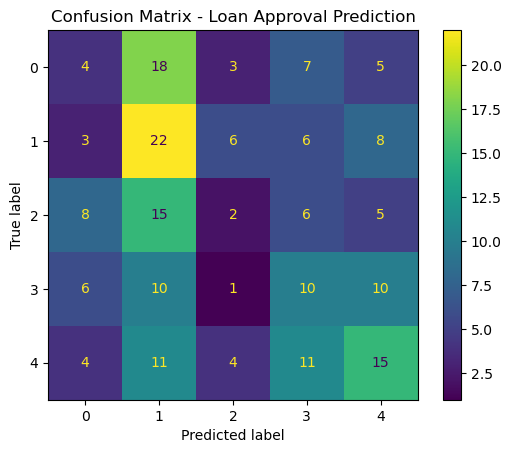

In [12]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix - Loan Approval Prediction")

plt.show()